In [48]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aljarah/xAPI-Edu-Data")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'xapi-edu-data' dataset.
Path to dataset files: /kaggle/input/xapi-edu-data


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [50]:
df = pd.read_csv(path +"/xAPI-Edu-Data.csv")
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [51]:
df.columns

Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands',
       'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='object')

In [52]:
#EDA
#1 check null value
df.isnull().sum()

,0
gender,0
NationalITy,0
PlaceofBirth,0
StageID,0
GradeID,0
SectionID,0
Topic,0
Semester,0
Relation,0
raisedhands,0


In [53]:
#2 check for target variables
df['GradeID'].value_counts()

,count
GradeID,
G-02,147
G-08,116
G-07,101
G-04,48
G-06,32
G-11,13
G-12,11
G-09,5
G-10,4


In [54]:
df['Class'].unique()

array(['M', 'L', 'H'], dtype=object)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

In [56]:
df['Class'].value_counts()

,count
Class,
M,211
H,142
L,127


<Axes: xlabel='Class', ylabel='count'>

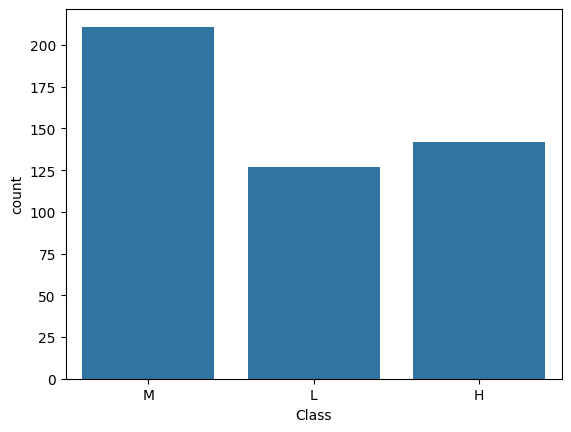

In [57]:
#Data type
#Classification -> one problem occurs which is class imbalance
sns.countplot(x=df['Class'])

In [58]:
# A bit of EDA part of skip which you guys have to perform

In [59]:
#Encoding all the object type columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('Class')

df = pd.get_dummies(df,columns=cat_cols)
df['Class'] = df['Class'].map({'M':0,'L':1,'H':2})

In [60]:
df.head()

,raisedhands,VisITedResources,AnnouncementsView,Discussion,Class,gender_F,gender_M,NationalITy_Egypt,NationalITy_Iran,NationalITy_Iraq,...,Semester_F,Semester_S,Relation_Father,Relation_Mum,ParentAnsweringSurvey_No,ParentAnsweringSurvey_Yes,ParentschoolSatisfaction_Bad,ParentschoolSatisfaction_Good,StudentAbsenceDays_Above-7,StudentAbsenceDays_Under-7
0,15,16,2,20,0,False,True,False,False,False,...,True,False,True,False,False,True,False,True,False,True
1,20,20,3,25,0,False,True,False,False,False,...,True,False,True,False,False,True,False,True,False,True
2,10,7,0,30,1,False,True,False,False,False,...,True,False,True,False,True,False,True,False,True,False
3,30,25,5,35,1,False,True,False,False,False,...,True,False,True,False,True,False,True,False,True,False
4,40,50,12,50,0,False,True,False,False,False,...,True,False,True,False,True,False,True,False,True,False


In [61]:
#model building
#KNN classification
#KNN is a distance based algorithm and because of this we are going to perfrom standard scaling


In [62]:
# Lets now split X and Y Variables
x = df.drop('Class',axis=1)
y = df['Class']

In [63]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [64]:
#standard scaling -> we will perfrom this scaling to avoid data leakage'

# mean = 0 AND STD DEVIATION = 2
# z - score = x_mean / std

In [65]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

In [65]:
#model build , train ,predict , evalutate